In [7]:
import pygimli as pg 
import matplotlib.pyplot as plt
import numpy as np
from pygimli.physics import ert
import pygimli.meshtools as mt

14/03/26 - 19:50:30 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


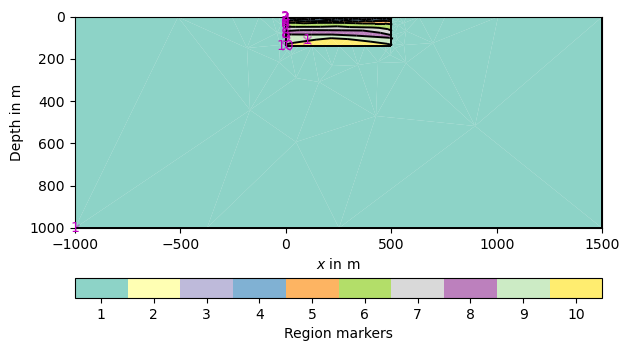

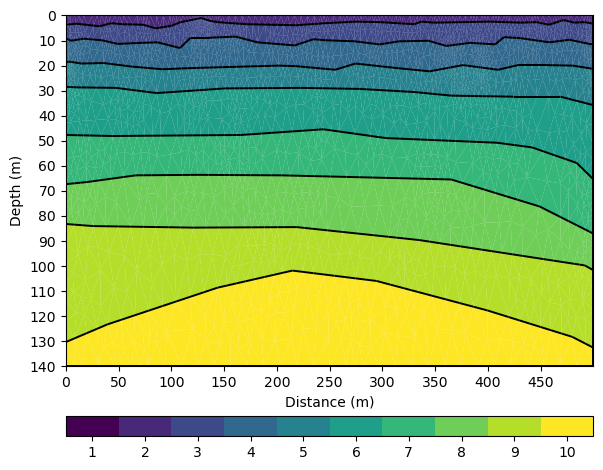

In [ ]:
world=mt.createWorld(start=[-1000,0],end=[1500,-1000],worldMarker=1)

poly=mt.createRectangle(start=[0, -140], end=[500, 0], marker=1)

interfaces = []

for i in range(9):

    coords = np.loadtxt(f'shape_{i}.txt')
    line = mt.createPolygon(coords, isClosed=False)
    interfaces.append(line)

geom = mt.mergePLC([world] + interfaces + [poly])

geom.addRegionMarker(pos=[0, -1], marker=2)
geom.addRegionMarker(pos=[0, -6], marker=3)
geom.addRegionMarker(pos=[0, -12], marker=4)
geom.addRegionMarker(pos=[0, -23], marker=5)
geom.addRegionMarker(pos=[0, -40], marker=6)
geom.addRegionMarker(pos=[0, -60], marker=7)
geom.addRegionMarker(pos=[0, -80], marker=8)
geom.addRegionMarker(pos=[0, -100], marker=9)
geom.addRegionMarker(pos=[0, -140], marker=10)


pg.show(geom,showMesh=True,quality=34)

mesh_cut = mt.createMesh(geom, quality=34)

x_min,x_max= 0,500
y_min,y_max= -140,0

ax, cbar = pg.show(mesh_cut, data=mesh_cut.cellMarkers(), 
                   showMesh=False, aspect='auto', 
                   cmap=plt.get_cmap("viridis", 10))
cbar.mappable.set_clim(0.5, 10.5)
cbar.set_ticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

ax.set_xlim(0, 500)
ax.set_ylim(-140, 0)
ax.set_yticks(np.arange(-140, 1, 10)) 
ax.set_xticks(np.arange(0, 500, 50)) 
ax.set_xlabel("Distance (m)")   
ax.set_ylabel("Depth (m)")

plt.draw()

14/03/26 - 19:50:36 - pyGIMLi - INFO - Cache c:\Users\sider\.conda\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 8): C:\Users\sider\AppData\Roaming\pygimli\Cache\17970140561219481632


Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']


(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x21f23279110>)

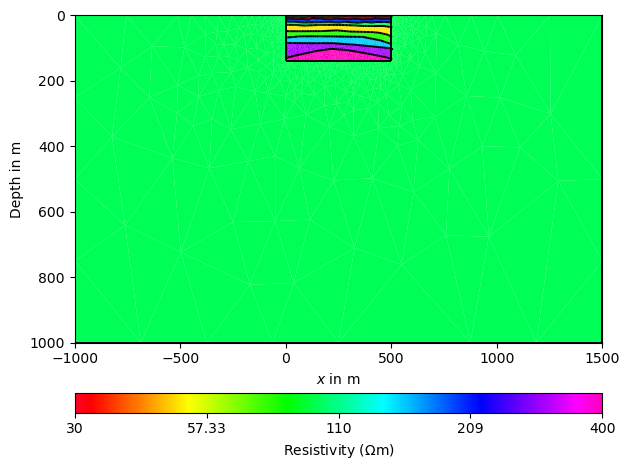

In [ ]:
spacing=25
scheme=ert.createData(
    elecs=np.linspace(start=0,stop=500,num=len(np.arange(0,501,spacing)))
    , schemeName='dd'
)
print(scheme)
for p in scheme.sensors():
    geom.createNode(p)
    geom.createNode(p-[0,0.1]) # create 2  nodes for FTDT
mesh_fwr=mt.createMesh(geom,quality=34)
rhomap=[[1,100],
        [2,100],
        [3,30],
        [4,200],
        [5,100],
        [6,50],
        [7,80],
        [8,150],
        [9,300],
        [10,400]
        ] # resistivity για κάθε marker
pg.show(mesh_fwr,data=rhomap,label=pg.unit('res'), cMap='gist_rainbow',logScale=True,aspect='auto')

In [10]:
data=ert.simulate(mesh_fwr,scheme=scheme, res=rhomap, noiseLevel=5, noiseAbs=1e-6, seed=1337)

pg.info(np.linalg.norm(data['err']),np.linalg.norm(data['rhoa']))
pg.info('Simulated data: ',data)
pg.info('The data contains : ',data.dataMap().keys())
pg.info('Sim rhoa (min/max) : ' ,min(data['rhoa']), max(data['rhoa']))
pg.info('Selected data noise % (min/ma)x : ', min(data['err'])*100, max(data['err'])*100)

14/03/26 - 19:50:41 - pyGIMLi - INFO - Data error estimate (min:max)  0.05000646492989695 : 0.05498040002706264
14/03/26 - 19:50:41 - pyGIMLi - INFO - 0.662636985614011 1229.5566691596337
14/03/26 - 19:50:41 - pyGIMLi - INFO - Simulated data:  Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
14/03/26 - 19:50:41 - pyGIMLi - INFO - The data contains :  ['a', 'b', 'err', 'i', 'ip', 'iperr', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
14/03/26 - 19:50:41 - pyGIMLi - INFO - Sim rhoa (min/max) :  57.690391453248104 140.35602680087445
14/03/26 - 19:50:41 - pyGIMLi - INFO - Selected data noise % (min/ma)x :  5.000646492989695 5.498040002706264


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100


14/03/26 - 19:50:43 - pyGIMLi - INFO - filtered rhoa minmax dd :  57.690391453248104 140.35602680087445


(<Axes: xlabel='a', ylabel='m'>,
 <matplotlib.colorbar.Colorbar at 0x21f0b406ed0>)

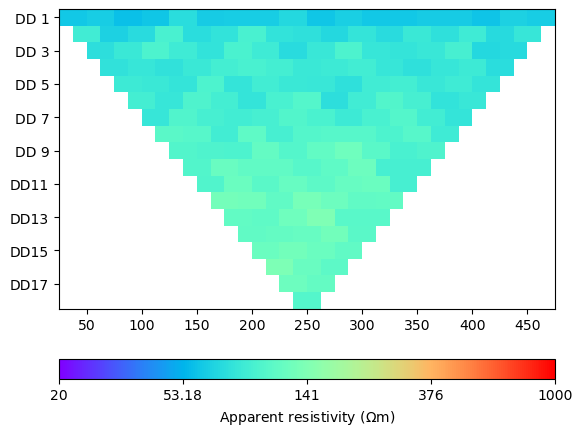

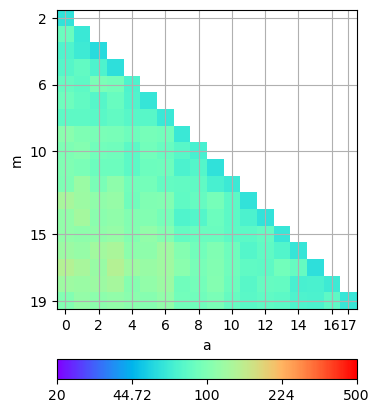

In [11]:
data.remove(data['rhoa']<0)
pg.info('filtered rhoa minmax dd : ', min(data['rhoa']), max(data['rhoa']))
#an thelw kanw save
data.save('fwd_t_dd.dat')
ert.show(data,cMap='rainbow',cMin=20,cMax=1000,logScale=True,title='DD')   #pseudosection
pg.viewer.mpl.showDataContainerAsMatrix(data,'a','m', 'rhoa',cMap='rainbow',cMin=20,cMax=500,logScale=True,title='DD')

In [12]:

np.save("abmn_t_dd.npy", np.column_stack([data['a'], data['b'], data['m'], data['n']]))
np.save("res_all_t_dd.npy", np.column_stack([data['rhoa']]))
abmn_data_dd = np.load("abmn_t_dd.npy")
print(abmn_data_dd)
print('------------------------------')
res_data_dd=np.load("res_all_t_dd.npy")
print(res_data_dd)

[[ 0  1  2  3]
 [ 1  2  3  4]
 [ 2  3  4  5]
 [ 3  4  5  6]
 [ 4  5  6  7]
 [ 5  6  7  8]
 [ 6  7  8  9]
 [ 7  8  9 10]
 [ 8  9 10 11]
 [ 9 10 11 12]
 [10 11 12 13]
 [11 12 13 14]
 [12 13 14 15]
 [13 14 15 16]
 [14 15 16 17]
 [15 16 17 18]
 [16 17 18 19]
 [17 18 19 20]
 [ 0  1  3  4]
 [ 1  2  4  5]
 [ 2  3  5  6]
 [ 3  4  6  7]
 [ 4  5  7  8]
 [ 5  6  8  9]
 [ 6  7  9 10]
 [ 7  8 10 11]
 [ 8  9 11 12]
 [ 9 10 12 13]
 [10 11 13 14]
 [11 12 14 15]
 [12 13 15 16]
 [13 14 16 17]
 [14 15 17 18]
 [15 16 18 19]
 [16 17 19 20]
 [ 0  1  4  5]
 [ 1  2  5  6]
 [ 2  3  6  7]
 [ 3  4  7  8]
 [ 4  5  8  9]
 [ 5  6  9 10]
 [ 6  7 10 11]
 [ 7  8 11 12]
 [ 8  9 12 13]
 [ 9 10 13 14]
 [10 11 14 15]
 [11 12 15 16]
 [12 13 16 17]
 [13 14 17 18]
 [14 15 18 19]
 [15 16 19 20]
 [ 0  1  5  6]
 [ 1  2  6  7]
 [ 2  3  7  8]
 [ 3  4  8  9]
 [ 4  5  9 10]
 [ 5  6 10 11]
 [ 6  7 11 12]
 [ 7  8 12 13]
 [ 8  9 13 14]
 [ 9 10 14 15]
 [10 11 15 16]
 [11 12 16 17]
 [12 13 17 18]
 [13 14 18 19]
 [14 15 19 20]
 [ 0  1  6